In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

import torch
from torch import nn
from torch import optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms, models
from collections import OrderedDict
from datetime import datetime
from PIL import Image

### Load and preprocess H&E patches

Unify patch sizes and split patches into train, validation, and test sets.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8267832..2.5528543].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8610327..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..2.6051416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..2.64].


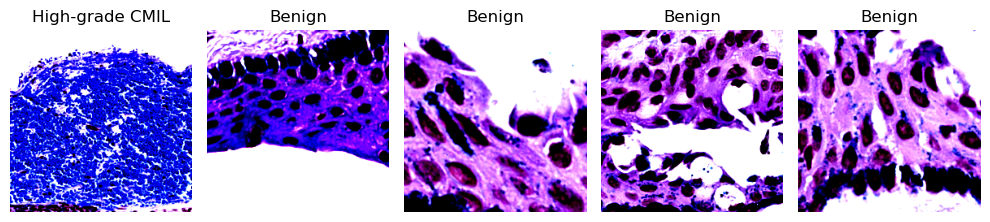

In [2]:
class PNGDataset(Dataset):
    def __init__(self, folder_path, transform=None):
        self.folder_path = folder_path
        self.transform = transform
        self.image_paths = [os.path.join(folder_path, fname) for fname in os.listdir(folder_path) if fname.endswith('.png')]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('RGB')  # Ensure images are in RGB format
        if self.transform:
            image = self.transform(image)
        if 'benign' in image_path: # 0 for benign, 1 for high-grade CMIL
            label = 0
        else:
            label = 1
        return image, label

image_folder_path = 'patch_outputs/'


transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = PNGDataset(folder_path=image_folder_path, transform=transform)
train_size = int(0.8 * len(dataset))  # 80% of total data for training
test_size = len(dataset) - train_size  # 20% of total data for testing
train_data, test_data = random_split(dataset, [train_size, test_size])
val_size = int(0.2 * train_size)  # 20% of training data for validation
train_size = train_size - val_size  # Remaining 80% for training
train_data, val_data = random_split(train_data, [train_size, val_size])
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)  # Shuffle training data
val_loader = DataLoader(val_data, batch_size=32, shuffle=True)  # Shuffle validation data
test_loader = DataLoader(test_data, batch_size=32, shuffle=False) # Do not shuffle test data

# visualize first few images in training set
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(figsize=(10, 4), ncols=5)
for i in range(5):
    axes[i].imshow(images[i].permute(1, 2, 0))
    axes[i].set_title('Benign' if labels[i] == 0 else 'High-grade CMIL')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### Build Image Classification Model using ResNet Architecture

Use ResNet with 50 layers. Fix model parameters, fine-tuning only last layer to output probability of each image belonging to a specific class.

In [3]:
def validation(model, criterion, val_loader):
    val_loss = 0
    accuracy = 0

    for images, labels in iter(val_loader):
        output = model.forward(images)
        val_loss += criterion(output, labels).item()

        probabilities = torch.exp(output)

        equality = labels.data == probabilities.max(dim=1)[1]
        accuracy += equality.type(torch.FloatTensor).mean()

    return val_loss, accuracy

In [4]:
# Training loop

def train_model(model, optimizer, criterion, train_loader, val_loader, epochs=5):
    plot_training = []
    plot_validation = []

    for e in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in iter(train_loader):
            optimizer.zero_grad()

            output = model.forward(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # Evaluate performance of each epoch
        model.eval()

        # Turn off gradients for validation, saves memory and computations
        with torch.no_grad():
            validation_loss, accuracy = validation(model, criterion, val_loader)

        print(
            "Epoch: {}/{}.. ".format(e + 1, epochs),
            "Training Loss: {:.3f}.. ".format(running_loss),
            "Validation Loss: {:.3f}.. ".format(
                validation_loss / len(val_loader)
            ),
            "Validation Accuracy: {:.3f}".format(accuracy / len(val_loader)),
        )

        plot_training.append(running_loss)
        plot_validation.append(validation_loss / len(val_loader))
    
    plt.plot(range(len(plot_training)), plot_training, label='training')
    plt.plot(range(len(plot_validation)), plot_validation, label='validation')
    plt.legend()
    plt.show()

    return model

In [5]:
def save_checkpoint(model, class_mapping, arch):
    """
    Save trained model weights.

    Input:
    arch(str): Model architecture
    """

    checkpoint = {
        "arch": arch,
        "class_to_idx": class_mapping,
        "model_state_dict": model.state_dict(),
    }

    timestamp = datetime.now().date().strftime("%Y%m%d")
    torch.save(checkpoint, f"../checkpoint/{timestamp}_{arch}.pth")

In [6]:
# Instantiate resnet50 model
model = models.resnet50(weights=True)

# Freeze pretrained model parameters to avoid backpropogating through them
for parameter in model.parameters():
    parameter.requires_grad = False

# Build custom classifier
num_classes = 2
num_ftrs = model.fc.in_features
classifier = nn.Sequential(
    OrderedDict(
        [
            ("fc", nn.Linear(num_ftrs, num_classes)),
            ("output", nn.LogSoftmax(dim=1)),
        ]
    )
)
model.fc = classifier

print("\nModified final layer")
print(model.fc)

/Users/sharonlins1428/miniconda3/envs/default/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Modified final layer
Sequential(
  (fc): Linear(in_features=2048, out_features=2, bias=True)
  (output): LogSoftmax(dim=1)
)


In [7]:
# Loss function and gradient descent
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

Epoch: 1/5..  Training Loss: 2.526..  Validation Loss: 0.512..  Validation Accuracy: 0.852
Epoch: 2/5..  Training Loss: 1.642..  Validation Loss: 0.384..  Validation Accuracy: 0.852
Epoch: 3/5..  Training Loss: 1.198..  Validation Loss: 0.321..  Validation Accuracy: 0.852
Epoch: 4/5..  Training Loss: 0.845..  Validation Loss: 0.261..  Validation Accuracy: 0.926
Epoch: 5/5..  Training Loss: 0.737..  Validation Loss: 0.241..  Validation Accuracy: 0.926


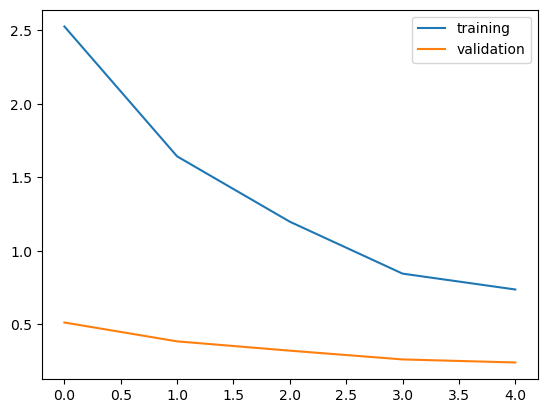

In [8]:
# Train model for 5 epochs
resnet_model = train_model(model, optimizer, criterion, train_loader, val_loader)

In [10]:
# Test model performance -- highly likely that the model is overfitting to the input data
# since the current dataset is very small (4 slices only)

from sklearn.metrics import classification_report

model.eval()

with torch.no_grad():
    predictions = []
    true_labels = []

    for images, labels in iter(test_loader):
        output = model.forward(images)
        probabilities = torch.exp(output)
        predictions += probabilities.max(dim=1)[1].tolist()
        true_labels += labels.tolist()

print(classification_report(true_labels, predictions))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95        27
           1       1.00      0.62      0.77         8

    accuracy                           0.91        35
   macro avg       0.95      0.81      0.86        35
weighted avg       0.92      0.91      0.91        35

